In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    silhouette_score
)

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

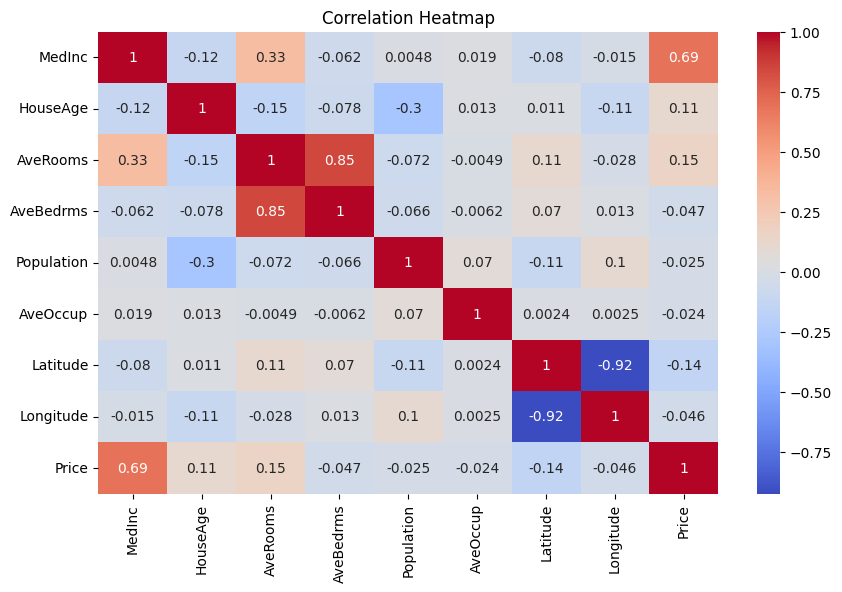

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [5]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

In [15]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


In [11]:
df["Class"] = (df["Price"] > df["Price"].median()).astype(int)

X_class = df.drop(["Price", "Class"], axis=1)

y_class = df["Class"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)
scaler2 = StandardScaler()

Xc_train = scaler2.fit_transform(Xc_train)

Xc_test = scaler2.transform(Xc_test)
log_model = LogisticRegression()

log_model.fit(Xc_train, yc_train)

yc_pred = log_model.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))

print("Precision:", precision_score(yc_test, yc_pred))

print("Recall:", recall_score(yc_test, yc_pred))

print(confusion_matrix(yc_test, yc_pred))

Accuracy: 0.8260658914728682
Precision: 0.8252806246949732
Recall: 0.8244758654314969
[[1719  358]
 [ 360 1691]]


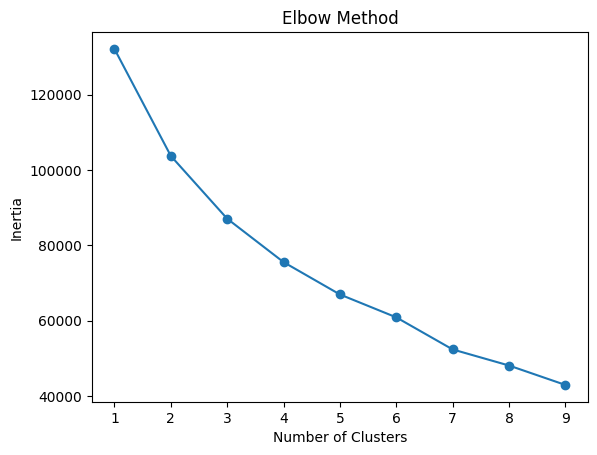

Silhouette Score: 0.3332598626054159


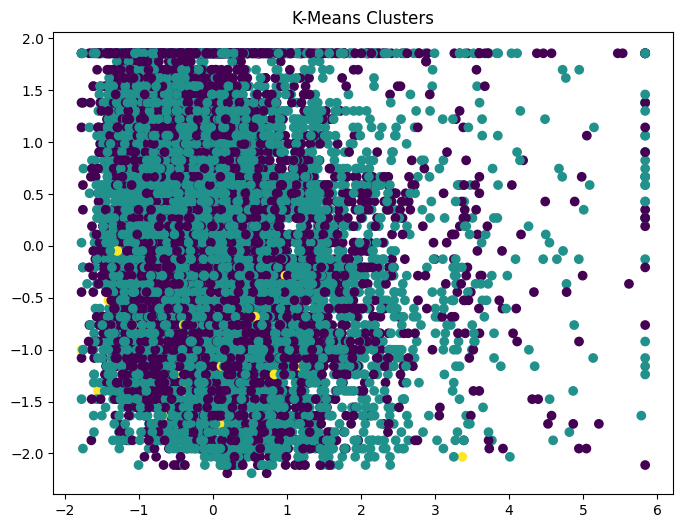

In [13]:
inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_train_scaled)
score = silhouette_score(X_train_scaled, clusters)

print("Silhouette Score:", score)
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=clusters
)

plt.title("K-Means Clusters")

plt.show()